In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import os
import datetime
from datetime import timedelta
from datetime import datetime
from matplotlib import ticker
from matplotlib.axes import Axes
import matplotlib
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import stats
import matplotlib.dates as mdates
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker
import shapefile as shp
import matplotlib.patches as patches
#from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

GeoAxes._pcolormesh_patched = Axes.pcolormesh

# Open and process data

In [2]:
# Temperature data
temp_dir = '/discover/nobackup/civanovi/data/MERRA2/2mtas_daily_maximum_global/annual_files/*'
global_temp_data = xr.open_mfdataset(temp_dir, parallel = True, combine = 'by_coords').T2M

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not 

In [3]:
# WBGT data
WBGT_dir = '/discover/nobackup/civanovi/data/MERRA2/WBGT_daily_summary_statistics_global/annual_files/*.nc'
global_WBGT_data = xr.open_mfdataset(WBGT_dir, parallel = True, combine = 'by_coords').WBGT_max

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 32:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 494 in H5O__attr_open_by_name(): can't locate attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Object not found
HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 32:
  #000: H5A.c line 528 in H5

## Calculate T95 and WBGT95 days and save out

In [4]:
# Select only early period

early_period = ['01-01-1980', '12-31-1989']
early_period_title = 'Early Period: 1980-1989'

global_temp_early = global_temp_data.sel(time = slice(early_period[0],early_period[1]))
global_WBGT_early = global_WBGT_data.sel(time = slice(early_period[0],early_period[1]))

In [5]:
global_95thpercentile_temp = global_temp_early.chunk(dict(time=-1)).quantile(0.95, dim = 'time')

In [6]:
global_95thpercentile_WBGT = global_WBGT_early.chunk(dict(time=-1)).quantile(0.95, dim = 'time')

In [8]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'
global_95thpercentile_temp.to_netcdf(save_dir + '95th_percentile_Tmax_global_1980-1989_baseperiod.nc')

In [7]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'
global_95thpercentile_WBGT.to_netcdf(save_dir + '95th_percentile_WBGTmax_global_1980-1989_baseperiod.nc')

In [10]:
T95_days = xr.where(global_temp_data >= global_95thpercentile_temp, 1,0)
T95_days_monthly = T95_days.resample(time = '1M').sum()

In [15]:
WBGT95_days = xr.where(global_WBGT_data >= global_95thpercentile_WBGT, 1,0)
WBGT95_days_monthly = WBGT95_days.resample(time = '1M').sum()

In [16]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

T95_days.to_netcdf(save_dir + 'global_T95_days_daily_count_1980-1989_baseperiod.nc')
T95_days_monthly.to_netcdf(save_dir + 'global_T95_days_monthly_count_1980-1989_baseperiod.nc')

In [18]:
WBGT95_days.to_netcdf(save_dir + 'global_WBGT95_days_daily_count_1980-1989_baseperiod.nc')
WBGT95_days_monthly.to_netcdf(save_dir + 'global_WBGT95_days_monthly_count_1980-1989_baseperiod.nc')

## Calculate local heat seasons

In [2]:
data_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'
monthly_T95_count = xr.open_dataarray(data_dir + 'global_T95_days_monthly_count_1980-1989_baseperiod.nc')
monthly_WBGT95_count = xr.open_dataarray(data_dir + 'global_WBGT95_days_monthly_count_1980-1989_baseperiod.nc')

In [4]:
early_period = ['01-01-1980', '12-31-1989']
early_period_title = 'Early Period: 1980-1989'

monthly_T95_counts = monthly_T95_count.sel(time = slice(early_period[0],early_period[1])).groupby('time.month').sum()
monthly_WBGT95_counts = monthly_WBGT95_count.sel(time = slice(early_period[0],early_period[1])).groupby('time.month').sum()

In [5]:
datasets = [monthly_T95_counts,monthly_WBGT95_counts]
month_num = 1

highest_T95_months = np.zeros((month_num,np.shape(monthly_T95_counts)[1], np.shape(monthly_T95_counts)[2]))
highest_WBGT95_months = np.zeros((month_num,np.shape(monthly_WBGT95_counts)[1], np.shape(monthly_WBGT95_counts)[2]))

for k, data in enumerate(datasets):
    
    for i,lat in enumerate(tqdm(data.lat)):
        for j,lon in enumerate(data.lon):
            
            data_gc = data.sel(lat = lat, lon = lon)
            months_toadd = data_gc.sortby(data_gc, ascending = False)[:month_num].month.values

            if k == 0:
                highest_T95_months[:,i,j] = months_toadd
            if k == 1:
                highest_WBGT95_months[:,i,j] = months_toadd

100%|██████████| 361/361 [05:04<00:00,  1.18it/s]


In [11]:
np.shape(np.squeeze(highest_T95_months))

(361, 576)

In [12]:
# Save out text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

np.savetxt(save_dir + 'month_highestT95_1980-1989_baseperiod.txt', np.squeeze(highest_T95_months), delimiter=',')
np.savetxt(save_dir + 'month_highestWBGT95_1980-1989_baseperiod.txt', np.squeeze(highest_WBGT95_months), delimiter=',')

In [24]:
# Iterate through grid cells again

datasets = [highest_T95_months,highest_WBGT95_months]

consecutive_T95 = np.zeros((np.shape(monthly_T95_counts)[1], np.shape(monthly_T95_counts)[2]))
consecutive_WBGT95 = np.zeros((np.shape(monthly_WBGT95_counts)[1], np.shape(monthly_WBGT95_counts)[2]))

mid_month_T95 = np.zeros((np.shape(monthly_T95_counts)[1], np.shape(monthly_T95_counts)[2]))
mid_month_WBGT95 = np.zeros((np.shape(monthly_WBGT95_counts)[1], np.shape(monthly_WBGT95_counts)[2]))

for k, data in enumerate(datasets):
    
    for i in tqdm(range(np.shape(data)[1])):
        for j in range(np.shape(data)[2]):
            
            data_gc = data[:,i,j]

            # Sort by month
            sorted_array = np.sort(data_gc)

            if k == 0:
                if (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 1): # if no crossing across year
                    consecutive_T95[i,j] = 1
                    mid_month_T95[i,j] = sorted_array[1]
                elif (sorted_array[1] - sorted_array[0] == 10) & (sorted_array[2] - sorted_array[1] == 1): # if NOV, DEC, JAN, pick DEC
                    consecutive_T95[i,j] = 1
                    mid_month_T95[i,j] = sorted_array[2]
                elif (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 10): # if DEC, JAN, FEB, pick JAN
                    consecutive_T95[i,j] = 1
                    mid_month_T95[i,j] = sorted_array[0]
                else:
                    consecutive_T95[i,j] = 2
                    mid_month_T95[i,j] = np.nan
                    
            if k == 1:
                if (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 1):
                    consecutive_WBGT95[i,j] = 1
                    mid_month_WBGT95[i,j] = sorted_array[1]
                elif (sorted_array[1] - sorted_array[0] == 10) & (sorted_array[2] - sorted_array[1] == 1):
                    consecutive_WBGT95[i,j] = 1
                    mid_month_WBGT95[i,j] = sorted_array[2]
                elif (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 10):
                    consecutive_WBGT95[i,j] = 1
                    mid_month_WBGT95[i,j] = sorted_array[0]
                else:
                    consecutive_WBGT95[i,j] = 2
                    mid_month_WBGT95[i,j] = np.nan

            del sorted_array

100%|██████████| 361/361 [00:00<00:00, 513.24it/s]


In [25]:
# Save out text files
np.savetxt(save_dir + 'middlemonth_3month_highestT95_1980-1989_baseperiod.txt', mid_month_T95, delimiter=',')
np.savetxt(save_dir + 'middlemonth_3month_highestWBGT95_1980-1989_baseperiod.txt', mid_month_WBGT95, delimiter=',')

## Save out highest mean T and WBGT

In [27]:
# Find 3 hottest months per year at each grid cell
monthly_Tmean = global_temp_data.sel(time = slice(early_period[0],early_period[1])).groupby('time.month').mean()
monthly_WBGTmean = global_WBGT_data.sel(time = slice(early_period[0],early_period[1])).groupby('time.month').mean()

In [28]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'
monthly_Tmean.to_netcdf(save_dir + 'Tmean_monthly_global_1980-1989_baseperiod.nc')
print('Monthly Tmean saved.')
monthly_WBGTmean.to_netcdf(save_dir + 'WBGTmean_monthly_global_1980-1989_baseperiod.nc')
print('Monthly WBGTmean saved.')

Monthly Tmean saved.
Monthly WBGTmean saved.


In [29]:
# Open data
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

monthly_Tmean = xr.open_dataarray(save_dir + 'Tmean_monthly_global_1980-1989_baseperiod.nc')
monthly_WBGTmean = xr.open_dataarray(save_dir + 'WBGTmean_monthly_global_1980-1989_baseperiod.nc')

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 24:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not

In [30]:
datasets = [monthly_Tmean,monthly_WBGTmean]
month_num = 3

highest_T_months = np.zeros((month_num,np.shape(monthly_Tmean)[1], np.shape(monthly_Tmean)[2]))
highest_WBGT_months = np.zeros((month_num,np.shape(monthly_WBGTmean)[1], np.shape(monthly_WBGTmean)[2]))

for k, data in enumerate(datasets):
    
    for i,lat in enumerate(tqdm(data.lat)):
        for j,lon in enumerate(data.lon):
            
            data_gc = data.sel(lat = lat, lon = lon)
            months_toadd = data_gc.sortby(data_gc, ascending = False)[:month_num].month.values

            if k == 0:
                highest_T_months[:,i,j] = months_toadd
            if k == 1:
                highest_WBGT_months[:,i,j] = months_toadd

100%|██████████| 361/361 [03:46<00:00,  1.60it/s]


In [31]:
# Iterate through grid cells again

datasets = [highest_T_months,highest_WBGT_months]

consecutive_T = np.zeros((np.shape(monthly_Tmean)[1], np.shape(monthly_Tmean)[2]))
consecutive_WBGT = np.zeros((np.shape(monthly_WBGTmean)[1], np.shape(monthly_WBGTmean)[2]))

mid_month_T = np.zeros((np.shape(monthly_Tmean)[1], np.shape(monthly_Tmean)[2]))
mid_month_WBGT = np.zeros((np.shape(monthly_WBGTmean)[1], np.shape(monthly_WBGTmean)[2]))

for k, data in enumerate(datasets):
    
    for i in tqdm(range(np.shape(data)[1])):
        for j in range(np.shape(data)[2]):
            
            data_gc = data[:,i,j]

            # Sort by month
            sorted_array = np.sort(data_gc)

            if k == 0:
                if (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 1): # if no crossing across year
                    consecutive_T[i,j] = 1
                    mid_month_T[i,j] = sorted_array[1]
                elif (sorted_array[1] - sorted_array[0] == 10) & (sorted_array[2] - sorted_array[1] == 1): # if NOV, DEC, JAN, pick DEC
                    consecutive_T[i,j] = 1
                    mid_month_T[i,j] = sorted_array[2]
                elif (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 10): # if DEC, JAN, FEB, pick JAN
                    consecutive_T[i,j] = 1
                    mid_month_T[i,j] = sorted_array[0]
                else:
                    consecutive_T[i,j] = 2
                    mid_month_T[i,j] = np.nan
                    
            if k == 1:
                if (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 1):
                    consecutive_WBGT[i,j] = 1
                    mid_month_WBGT[i,j] = sorted_array[1]
                elif (sorted_array[1] - sorted_array[0] == 10) & (sorted_array[2] - sorted_array[1] == 1):
                    consecutive_WBGT[i,j] = 1
                    mid_month_WBGT[i,j] = sorted_array[2]
                elif (sorted_array[1] - sorted_array[0] == 1) & (sorted_array[2] - sorted_array[1] == 10):
                    consecutive_WBGT[i,j] = 1
                    mid_month_WBGT[i,j] = sorted_array[0]
                else:
                    consecutive_WBGT[i,j] = 2
                    mid_month_WBGT[i,j] = np.nan

            del sorted_array

100%|██████████| 361/361 [00:00<00:00, 517.41it/s]


In [32]:
# Save out text files

np.savetxt(save_dir + 'middlemonth_3month_highestT_1980-1989_baseperiod.txt', mid_month_T, delimiter=',')
np.savetxt(save_dir + 'middlemonth_3month_highestWBGT_1980-1989_baseperiod.txt', mid_month_WBGT, delimiter=',')

## Last main calculation step

In [2]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [3]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

In [4]:
data_dir = '/home/civanovi/JupyterLinks/nobackup/data/MERRA2/processed_data/'
monthly_T95_count = xr.open_dataarray(data_dir + 'global_T95_days_monthly_count_1980-1989_baseperiod.nc')
monthly_WBGT95_count = xr.open_dataarray(data_dir + 'global_WBGT95_days_monthly_count_1980-1989_baseperiod.nc')

In [5]:
early_period = ['01-01-1980', '12-31-1989']
early_period_title = 'Early Period: 1980-1989'

late_period = ['01-01-2015', '12-31-2024']
late_period_title = 'Late Period: 2015-2024'

monthly_T95_count_early = monthly_T95_count.sel(time = slice(early_period[0],early_period[1]))
monthly_WBGT95_count_early = monthly_WBGT95_count.sel(time = slice(early_period[0],early_period[1]))

monthly_T95_count_late = monthly_T95_count.sel(time = slice(late_period[0],late_period[1]))
monthly_WBGT95_count_late = monthly_WBGT95_count.sel(time = slice(late_period[0],late_period[1]))

In [6]:
monthly_T95_early_counts = monthly_T95_count_early.groupby('time.month').sum()
monthly_WBGT95_early_counts = monthly_WBGT95_count_early.groupby('time.month').sum()

monthly_T95_late_counts = monthly_T95_count_late.groupby('time.month').sum()
monthly_WBGT95_late_counts = monthly_WBGT95_count_late.groupby('time.month').sum()

In [7]:
# Open text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

mid_month_T = np.loadtxt(save_dir + 'middlemonth_3month_highestT_1980-1989_baseperiod.txt', delimiter=',')
mid_month_WBGT = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT_1980-1989_baseperiod.txt', delimiter=',')

mid_month_T95 = np.loadtxt('/discover/nobackup/civanovi/data/MERRA2/processed_data/' + 'middlemonth_3month_highestT95_1980-1989_baseperiod.txt', delimiter=',')
mid_month_WBGT95 = np.loadtxt('/discover/nobackup/civanovi/data/MERRA2/processed_data/' + 'middlemonth_3month_highestWBGT95_1980-1989_baseperiod.txt', delimiter=',')

In [8]:
# Iterate through each grid cell and determine what fraction of events happen in 2 months before and after heat season
datasets = [mid_month_T95,mid_month_WBGT95]
#extremes_datasets = [monthly_T95_counts,monthly_WBGT95_counts]
extremes_datasets_early = [monthly_T95_early_counts,monthly_WBGT95_early_counts]
extremes_datasets_late = [monthly_T95_late_counts,monthly_WBGT95_late_counts]

heat_season_extremes_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
before_extremes_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
after_extremes_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))

heat_season_extremes_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
before_extremes_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
after_extremes_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))

# Do this for full historical period, but then do for early and late historical period

for k, data in enumerate(datasets):

    #extremes_data = extremes_datasets[k]
    extremes_data_early = extremes_datasets_early[k]
    extremes_data_late = extremes_datasets_late[k]
    
    for i in tqdm(range(np.shape(data)[0])):
        
        for j in range(np.shape(data)[1]):

            mid_month = data[i,j]

            if (mid_month - mid_month) != 0:

                if k == 0:
                    heat_season_extremes_T[i,j] = np.nan
                    before_extremes_T[i,j] = np.nan
                    after_extremes_T[i,j] = np.nan
                else:
                    heat_season_extremes_WBGT[i,j] = np.nan
                    before_extremes_WBGT[i,j] = np.nan
                    after_extremes_WBGT[i,j] = np.nan

            else:
                #gc_extremes = extremes_data.isel(lat = i, lon = j)
                gc_extremes_early = extremes_data_early.isel(lat = i, lon = j)
                gc_extremes_late = extremes_data_late.isel(lat = i, lon = j)
    
                # Find heat season months
                if mid_month == 1:
                    heat_season = [12,1,2]
                elif mid_month == 12:
                    heat_season = [11,12,1]
                else:
                    heat_season = [mid_month-1,mid_month,mid_month+1]

                # Outside months
                before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
                after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

                # Adjust if this gives negative numbers
                before_season = [x if x > 0  else (x+12) for x in before_season_temp]

                after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

                # Find difference between early and late periods
                #heat_season_extremes = gc_extremes_late.sel(month = heat_season).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = heat_season).sum()/gc_extremes_early.sum()
                #before_extremes = gc_extremes_late.sel(month = before_season).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = before_season).sum()/gc_extremes_early.sum()
                #after_extremes = gc_extremes_late.sel(month = after_season).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = after_season).sum()/gc_extremes_early.sum()

                heat_season_extremes = gc_extremes_late.sel(month = heat_season).sum() - gc_extremes_early.sel(month = heat_season).sum()
                before_extremes = gc_extremes_late.sel(month = before_season).sum() - gc_extremes_early.sel(month = before_season).sum()
                after_extremes = gc_extremes_late.sel(month = after_season).sum() - gc_extremes_early.sel(month = after_season).sum()
                
                if k == 0:
                    heat_season_extremes_T[i,j] = heat_season_extremes
                    before_extremes_T[i,j] = before_extremes
                    after_extremes_T[i,j] = after_extremes
                else:
                    heat_season_extremes_WBGT[i,j] = heat_season_extremes
                    before_extremes_WBGT[i,j] = before_extremes
                    after_extremes_WBGT[i,j] = after_extremes

100%|██████████| 361/361 [15:43<00:00,  2.61s/it]


In [9]:
# Save out changes
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

# Temperature data
np.savetxt(save_dir + 'local_T_heat_season_T95_TOTALCOUNTS_1980-1989_baseperiod.txt', heat_season_extremes_T, delimiter=',')
np.savetxt(save_dir + 'local_T_heat_season_2monthsbefore_T95_TOTALCOUNTS_1980-1989_baseperiod.txt', before_extremes_T, delimiter=',')
np.savetxt(save_dir + 'local_T_heat_season_2monthsafter_T95_TOTALCOUNTS_1980-1989_baseperiod.txt', after_extremes_T, delimiter=',')

# WBGT data
np.savetxt(save_dir + 'local_WBGT_heat_season_WBGT95_TOTALCOUNTS_1980-1989_baseperiod.txt', heat_season_extremes_WBGT, delimiter=',')
np.savetxt(save_dir + 'local_WBGT_heat_season_2monthsbefore_WBGT95_TOTALCOUNTS_1980-1989_baseperiod.txt', before_extremes_WBGT, delimiter=',')
np.savetxt(save_dir + 'local_WBGT_heat_season_2monthsafter_WBGT95_TOTALCOUNTS_1980-1989_baseperiod.txt', after_extremes_WBGT, delimiter=',')

# Load preprocessed data and plot

In [2]:
# Open preprocessed data
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

# Temperature data -- fraction
heat_season_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_T95_count_1980-1989_baseperiod.txt',  delimiter=',')
before_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsbefore_T95_count_1980-1989_baseperiod.txt',  delimiter=',')
after_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsafter_T95_count_1980-1989_baseperiod.txt',  delimiter=',')

# WBGT data -- fraction
heat_season_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_WBGT95_count_1980-1989_baseperiod.txt',  delimiter=',')
before_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsbefore_WBGT95_count_1980-1989_baseperiod.txt', delimiter=',')
after_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsafter_WBGT95_count_1980-1989_baseperiod.txt',  delimiter=',')

In [3]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [4]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

ocean_mask = xr.where(frac_land.mean(dim = 'time') <= 0.5, 1, np.nan)
ocean_mask.load();

ocean_array = ocean_mask.to_numpy()

0.04610655737704918
0.07203067950697149


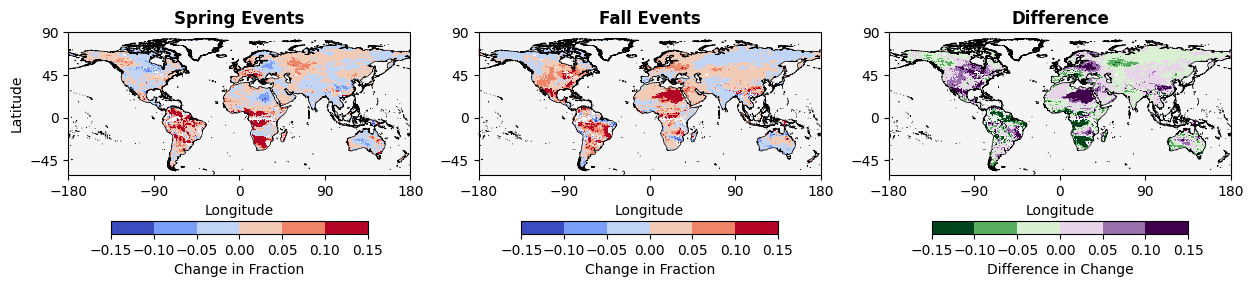

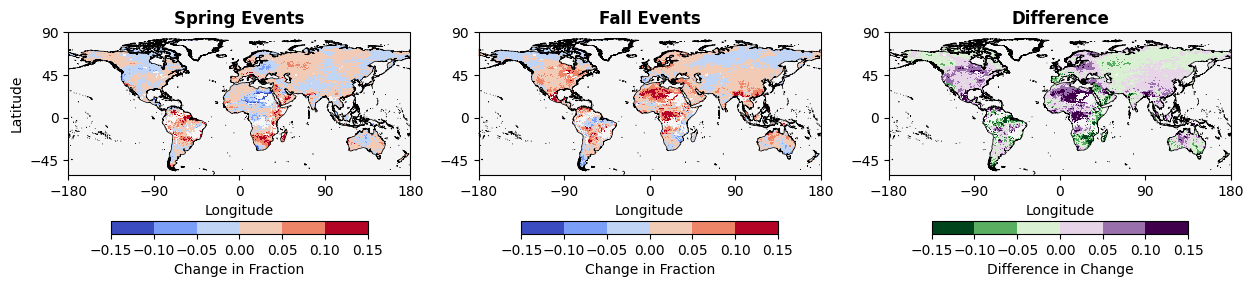

In [6]:
# Find difference between panel 2 and three in each figure
T_datasets = [before_extremes_T,after_extremes_T,after_extremes_T - before_extremes_T]
WBGT_datasets = [before_extremes_WBGT,after_extremes_WBGT,after_extremes_WBGT - before_extremes_WBGT]

titles = ['Spring Events','Fall Events','Difference']
cbar_labels = ['Change in Fraction','Change in Fraction', 'Difference in Change']

datasets = [T_datasets,WBGT_datasets]

test_lon = -116.57
test_lat = 38.7

for j, event_data in enumerate(datasets):

    fig, axs = plt.subplots(1,3,figsize = (15,12), facecolor = 'w', edgecolor = 'k', subplot_kw = {'projection': ccrs.PlateCarree()})
    
    for i, ax in enumerate(fig.axes):
    
        plot_data_masked = event_data[i]*mask_array

        plot_data_ds = xr.DataArray(plot_data_masked, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])
        if i == 2:
            cmap = matplotlib.cm.PRGn_r
            print(plot_data_ds.sel(lon = test_lon, lat = test_lat, method = 'nearest').values)
            #ax.scatter(test_lon,test_lat, c = 'crimson', s = 10, zorder = 10)
        else:
            cmap = matplotlib.cm.coolwarm

        bounds = np.arange(-0.15, 0.15 + 0.05, 0.05) # if frac
        #bounds = np.arange(-60, 60 +10, 10) # if counts
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('whitesmoke',1.)
    
        mesh = ax.pcolormesh(plot_data_ds.lon, plot_data_ds.lat, plot_data_ds, norm = norm, cmap = cmap)

        # Add significance stippling
       # if i < 2:
       #     sig_data_masked = sig_data[i]*mask_array
       #     sig_mask = (sig_data_masked > 0.05)
       #     conf = ax.contourf(plot_data_ds.lon, plot_data_ds.lat, sig_mask, hatches=['', '...'], alpha=0)
    
        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            ax.plot(x,y, color = 'k', linewidth = 0.5)
    
        ax.set_title(titles[i], fontweight = 'bold')

        ax.set_xlim([-180,180])
        ax.set_ylim([-60,90])
        ax.set_xticks([-180,-90,0,90,180]);
        ax.set_yticks([-45,0,45,90]);
        ax.set_xlabel('Longitude')

        if i == 0:
            ax.set_ylabel('Latitude')

        cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='horizontal', ax = ax,
                            label=cbar_labels[i], shrink = 0.75, pad = 0.05)

# Add in shoulder pad seasons

In [5]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [6]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

In [7]:
data_dir = '/home/civanovi/JupyterLinks/nobackup/data/MERRA2/processed_data/'
monthly_T95_count = xr.open_dataarray(data_dir + 'global_T95_days_monthly_count_1980-1989_baseperiod.nc')
monthly_WBGT95_count = xr.open_dataarray(data_dir + 'global_WBGT95_days_monthly_count_1980-1989_baseperiod.nc')

In [8]:
early_period = ['01-01-1980', '12-31-1989']
early_period_title = 'Early Period: 1980-1989'

late_period = ['01-01-2015', '12-31-2024']
late_period_title = 'Late Period: 2015-2024'

monthly_T95_count_early = monthly_T95_count.sel(time = slice(early_period[0],early_period[1]))
monthly_WBGT95_count_early = monthly_WBGT95_count.sel(time = slice(early_period[0],early_period[1]))

monthly_T95_count_late = monthly_T95_count.sel(time = slice(late_period[0],late_period[1]))
monthly_WBGT95_count_late = monthly_WBGT95_count.sel(time = slice(late_period[0],late_period[1]))

In [9]:
monthly_T95_early_counts = monthly_T95_count_early.groupby('time.month').sum()
monthly_WBGT95_early_counts = monthly_WBGT95_count_early.groupby('time.month').sum()

monthly_T95_late_counts = monthly_T95_count_late.groupby('time.month').sum()
monthly_WBGT95_late_counts = monthly_WBGT95_count_late.groupby('time.month').sum()

In [10]:
# Open text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

mid_month_T = np.loadtxt(save_dir + 'middlemonth_3month_highestT_1980-1989_baseperiod.txt', delimiter=',')
mid_month_WBGT = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT_1980-1989_baseperiod.txt', delimiter=',')

mid_month_T95 = np.loadtxt('/discover/nobackup/civanovi/data/MERRA2/processed_data/' + 'middlemonth_3month_highestT95_1980-1989_baseperiod.txt', delimiter=',')
mid_month_WBGT95 = np.loadtxt('/discover/nobackup/civanovi/data/MERRA2/processed_data/' + 'middlemonth_3month_highestWBGT95_1980-1989_baseperiod.txt', delimiter=',')

In [12]:
# Iterate through each grid cell and determine what fraction of events happen in 2 months before and after heat season
datasets = [mid_month_T95,mid_month_WBGT95]
extremes_datasets_early = [monthly_T95_early_counts,monthly_WBGT95_early_counts]
extremes_datasets_late = [monthly_T95_late_counts,monthly_WBGT95_late_counts]

before_pad_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
after_pad_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))

before_pad_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
after_pad_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))

# Do this for full historical period, but then do for early and late historical period

for k, data in enumerate(datasets):

    extremes_data_early = extremes_datasets_early[k]
    extremes_data_late = extremes_datasets_late[k]
    
    for i in tqdm(range(np.shape(data)[0])):
        
        for j in range(np.shape(data)[1]):

            mid_month = data[i,j]

            if (mid_month - mid_month) != 0:

                if k == 0:
                    before_pad_T[i,j] = np.nan
                    after_pad_T[i,j] = np.nan
                else:
                    before_pad_WBGT[i,j] = np.nan
                    after_pad_WBGT[i,j] = np.nan

            else:
                gc_extremes_early = extremes_data_early.isel(lat = i, lon = j)
                gc_extremes_late = extremes_data_late.isel(lat = i, lon = j)
    
                # Find heat season months
                if mid_month == 1:
                    heat_season = [12,1,2]
                elif mid_month == 12:
                    heat_season = [11,12,1]
                else:
                    heat_season = [mid_month-1,mid_month,mid_month+1]

                # Outside months
                before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
                after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

                # Adjust if this gives negative numbers
                before_season = [x if x > 0  else (x+12) for x in before_season_temp]

                after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

                # Calculate before pad and after pad season
                before_pad_season = before_season
                before_pad_season.append(heat_season[0])
                
                after_pad_season = after_season
                after_pad_season.append(heat_season[2])

                # Find difference between early and late periods
                #before_pad_extremes = gc_extremes_late.sel(month = before_pad_season).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = before_pad_season).sum()/gc_extremes_early.sum()
                #after_pad_extremes = gc_extremes_late.sel(month = after_pad_season).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = after_pad_season).sum()/gc_extremes_early.sum()

                # If just want first and last month of heat season
                before_pad_extremes = gc_extremes_late.sel(month = heat_season[0]).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = heat_season[0]).sum()/gc_extremes_early.sum()
                after_pad_extremes = gc_extremes_late.sel(month = heat_season[2]).sum()/gc_extremes_late.sum() - gc_extremes_early.sel(month = heat_season[2]).sum()/gc_extremes_early.sum()
                
                if k == 0:
                    before_pad_T[i,j] = before_pad_extremes
                    after_pad_T[i,j] = after_pad_extremes
                else:
                    before_pad_WBGT[i,j] = before_pad_extremes
                    after_pad_WBGT[i,j] = after_pad_extremes

100%|██████████| 361/361 [14:26<00:00,  2.40s/it]


In [13]:
# Save out changes
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

# Temperature data
#np.savetxt(save_dir + 'local_T_heat_season_before_shoulderpad_T95_count_1980-1989_baseperiod.txt', before_pad_T, delimiter=',')
#np.savetxt(save_dir + 'local_T_heat_season_after_shoulderpad_T95_count_1980-1989_baseperiod.txt', after_pad_T, delimiter=',')
#np.savetxt(save_dir + 'local_T_heat_season_firstmonth_T95_count_1980-1989_baseperiod.txt', before_pad_T, delimiter=',')
#np.savetxt(save_dir + 'local_T_heat_season_lastmonth_T95_count_1980-1989_baseperiod.txt', after_pad_T, delimiter=',')

# WBGT data
#np.savetxt(save_dir + 'local_WBGT_heat_season_before_shoulderpad_WBGT95_count_1980-1989_baseperiod.txt', before_pad_WBGT, delimiter=',')
#np.savetxt(save_dir + 'local_WBGT_heat_season_after_shoulderpad_WBGT95_count_1980-1989_baseperiod.txt', after_pad_WBGT, delimiter=',')
#np.savetxt(save_dir + 'local_WBGT_heat_season_firstmonth_WBGT95_count_1980-1989_baseperiod.txt', before_pad_WBGT, delimiter=',')
#np.savetxt(save_dir + 'local_WBGT_heat_season_lastmonth_WBGT95_count_1980-1989_baseperiod.txt', after_pad_WBGT, delimiter=',')

## Load preprocessed and plot

In [7]:
# Open preprocessed data
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

# Temperature data -- fraction
before_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsbefore_T95_count_1980-1989_baseperiod.txt',  delimiter=',')
after_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsafter_T95_count_1980-1989_baseperiod.txt',  delimiter=',')
before_pad_T = np.loadtxt(save_dir + 'baseperiod_1980s/' + 'local_T_heat_season_firstmonth_T95_count_1980-1989_baseperiod.txt',  delimiter=',')
after_pad_T = np.loadtxt(save_dir + 'baseperiod_1980s/' + 'local_T_heat_season_lastmonth_T95_count_1980-1989_baseperiod.txt',  delimiter=',')

# WBGT data -- fraction
before_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsbefore_WBGT95_count_1980-1989_baseperiod.txt', delimiter=',')
after_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsafter_WBGT95_count_1980-1989_baseperiod.txt',  delimiter=',')
before_pad_WBGT = np.loadtxt(save_dir + 'baseperiod_1980s/' + 'local_WBGT_heat_season_firstmonth_WBGT95_count_1980-1989_baseperiod.txt',  delimiter=',')
after_pad_WBGT = np.loadtxt(save_dir + 'baseperiod_1980s/' + 'local_WBGT_heat_season_lastmonth_WBGT95_count_1980-1989_baseperiod.txt',  delimiter=',')

In [7]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [8]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

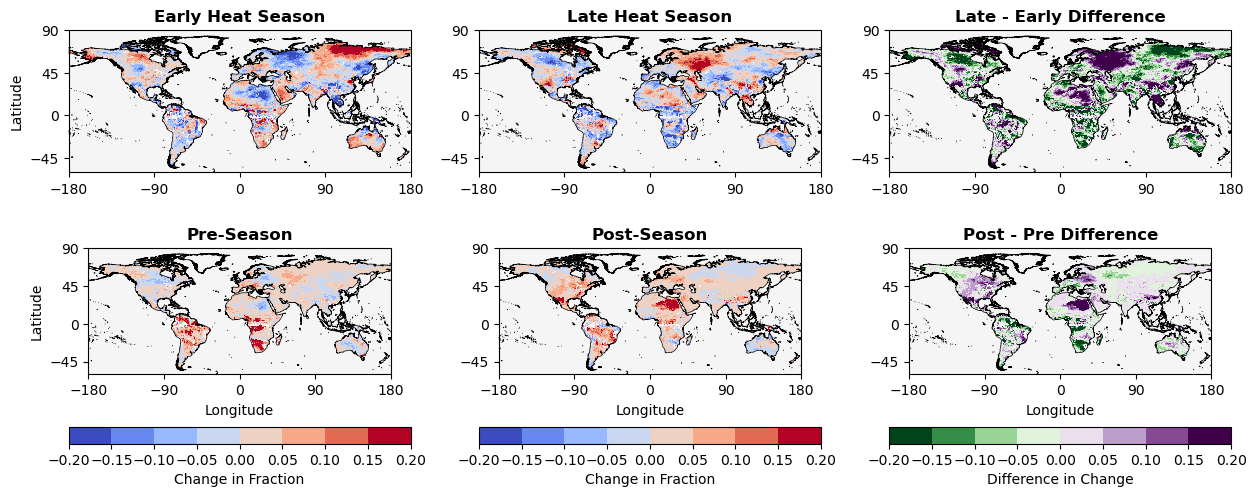

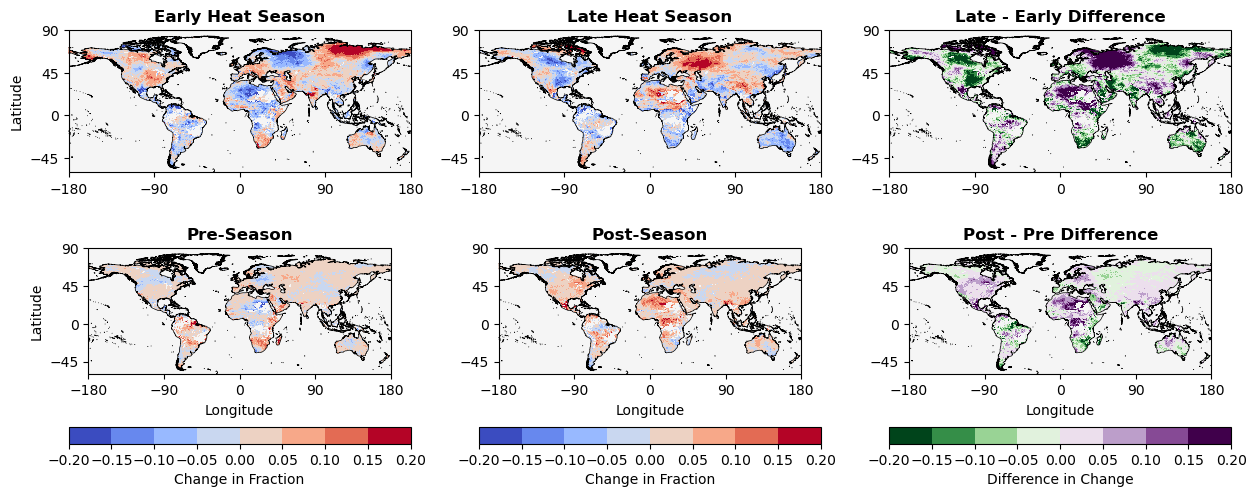

In [9]:
# Find difference between panel 2 and three in each figure
T_datasets = [before_pad_T,after_pad_T, after_pad_T - before_pad_T, before_extremes_T, after_extremes_T, after_extremes_T - before_extremes_T]
WBGT_datasets = [before_pad_WBGT,after_pad_WBGT, after_pad_WBGT - before_pad_WBGT, before_extremes_WBGT,after_extremes_WBGT, after_extremes_WBGT - before_extremes_WBGT]

titles = ['Early Heat Season', 'Late Heat Season','Late - Early Difference', 'Pre-Season','Post-Season', 'Post - Pre Difference']
cbar_labels = ['Change in Fraction','Change in Fraction','Difference in Change','Change in Fraction','Change in Fraction',  'Difference in Change']

datasets = [T_datasets,WBGT_datasets]

test_lon = -116.57
test_lat = 38.7

for j, event_data in enumerate(datasets):

    fig, axs = plt.subplots(2,3,figsize = (15,6), facecolor = 'w', edgecolor = 'k', subplot_kw = {'projection': ccrs.PlateCarree()})
    
    for i, ax in enumerate(fig.axes):
    
        plot_data_masked = event_data[i]*mask_array

        plot_data_ds = xr.DataArray(plot_data_masked, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])
        if i in [2,5]:
            cmap = matplotlib.cm.PRGn_r
        else:
            cmap = matplotlib.cm.coolwarm

        bounds = np.arange(-0.2, 0.2 + 0.05, 0.05) # if frac
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('whitesmoke',1.)
    
        mesh = ax.pcolormesh(plot_data_ds.lon, plot_data_ds.lat, plot_data_ds, norm = norm, cmap = cmap)

        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            ax.plot(x,y, color = 'k', linewidth = 0.5)
    
        ax.set_title(titles[i], fontweight = 'bold')
        ax.set_xlim([-180,180])
        ax.set_ylim([-60,90])
        ax.set_xticks([-180,-90,0,90,180]);
        ax.set_yticks([-45,0,45,90]);

        if i in [0,3]:
            ax.set_ylabel('Latitude')

        if i > 2:
            ax.set_xlabel('Longitude')
            cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='horizontal', ax = ax,
                            label=cbar_labels[i], pad = 0.25)

# Plot as two columns

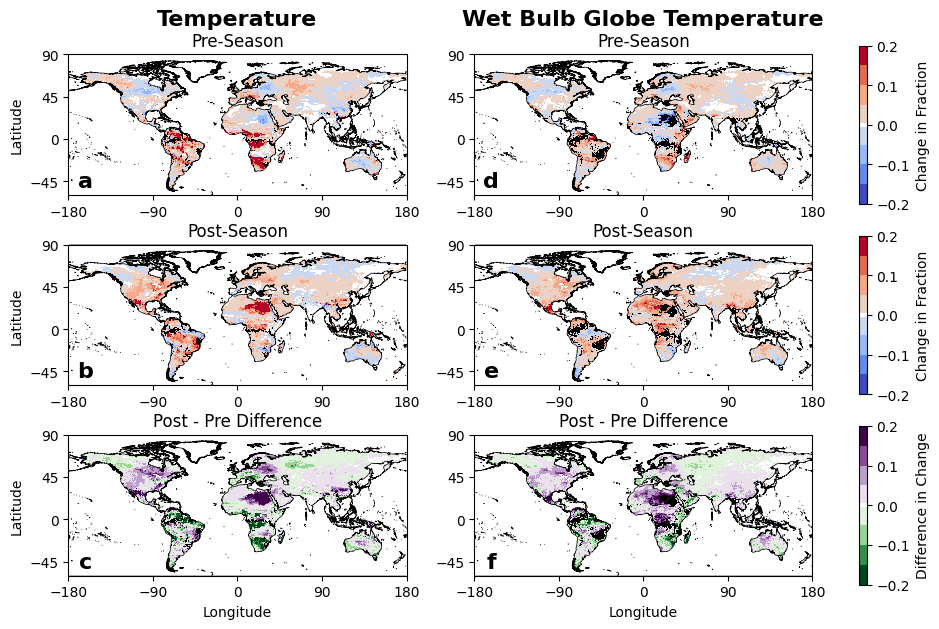

In [5]:
# Find difference between panel 2 and three in each figure
T_datasets = [before_extremes_T, after_extremes_T, after_extremes_T - before_extremes_T]
#T_datasets = [before_pad_T,after_pad_T, after_pad_T - before_pad_T]
WBGT_datasets = [before_extremes_WBGT,after_extremes_WBGT, after_extremes_WBGT - before_extremes_WBGT]
#WBGT_datasets = [before_pad_WBGT,after_pad_WBGT, after_pad_WBGT - before_pad_WBGT]

titles = ['Pre-Season','Post-Season', 'Post - Pre Difference']
#titles = ['Early Heat Season', 'Late Heat Season','Late - Early Difference']

cbar_labels = ['Change in Fraction','Change in Fraction','Difference in Change']
column_names = ['Temperature','Wet Bulb Globe Temperature']
panel_labels = [['a','b','c'],['d','e','f']]

datasets = [T_datasets,WBGT_datasets]

test_lon = -116.57
test_lat = 38.7

rows = 3
columns = 2

fig, axs = plt.subplots(rows,columns, figsize = (12,7), facecolor = 'w', edgecolor = 'k', subplot_kw = {'projection': ccrs.PlateCarree()})

for j, dataset in enumerate(datasets):
    
    for i, event_data in enumerate(dataset):
    
        plot_data_masked = event_data*mask_array
    
        plot_data_ds = xr.DataArray(plot_data_masked, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])
        if i == 2:
            cmap = matplotlib.cm.PRGn_r
        else:
            cmap = matplotlib.cm.coolwarm
    
        bounds = np.arange(-0.2, 0.2 + 0.05, 0.05) # if frac
        ticks = np.arange(-0.2,0.2 + 0.1, 0.1)
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('k',1.)
    
        mesh = axs[i,j].pcolormesh(plot_data_ds.lon, plot_data_ds.lat, plot_data_ds, norm = norm, cmap = cmap)

        # Make zero change white
        zero_change = np.ma.masked_array(plot_data_ds, plot_data_ds != 0)
        mesh_zero = axs[i,j].pcolormesh(plot_data_ds.lon, plot_data_ds.lat, zero_change, cmap = 'binary')

        # Plot ocean white on top of everything
        ocean_mesh = axs[i,j].pcolormesh(plot_data_ds.lon, plot_data_ds.lat, ocean_array, cmap = 'binary')
    
        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[i,j].plot(x,y, color = 'k', linewidth = 0.5)
    
        axs[i,j].set_title(titles[i])
        axs[i,j].set_xlim([-180,180])
        axs[i,j].set_ylim([-60,90])
        axs[i,j].set_xticks([-180,-90,0,90,180]);
        axs[i,j].set_yticks([-45,0,45,90]);
    
        if j == 0:
            axs[i,j].set_ylabel('Latitude')
        else:
            cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='vertical', ax = axs[i,:].ravel(),
                            label=cbar_labels[i])
            cbar.ax.set_yticks(ticks);
            cbar.ax.minorticks_off()
            cbar.ax.axhline(0, color='white', linewidth=3)
        if i == 2:
            axs[i,j].set_xlabel('Longitude')

        elif i == 0:
            axs[i,j].text(0.5, 1.25, column_names[j], transform=axs[i,j].transAxes, 
              fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')

        axs[i,j].text(0.05, 0.1, panel_labels[j][i], transform=axs[i,j].transAxes,
                     fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')

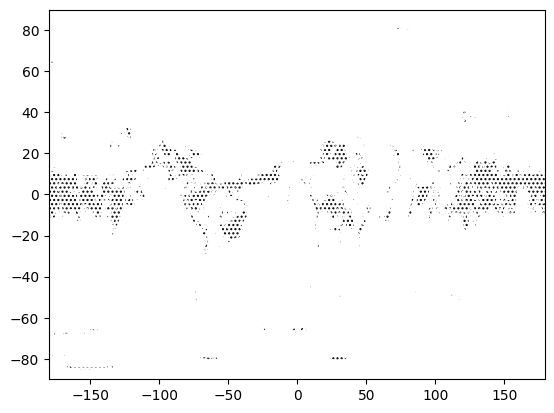

In [8]:
# Plot places with no heat season as hatched
no_heat_season = np.isnan(event_data)
conf = plt.contourf(frac_land.lon, frac_land.lat, no_heat_season, hatches=['', '....'], alpha=0)

In [8]:
# Calculate percent of grid cells shifting asymmetrically in each direction (both dry and humid)
T_diff = (after_extremes_T - before_extremes_T)*mask_array
WBGT_diff = (after_extremes_WBGT - before_extremes_WBGT)*mask_array

In [24]:
real_T = ~np.isnan(after_extremes_T*mask_array)
real_WBGT = ~np.isnan(after_extremes_WBGT*mask_array)

In [34]:
T_diff_1D = T_diff.ravel()
WBGT_diff_1D = WBGT_diff.ravel()

ind_fall_both = np.sum((T_diff_1D > 0) & (WBGT_diff_1D > 0))/np.sum(real_T*real_WBGT)
ind_spring_both = np.sum((T_diff_1D < 0) & (WBGT_diff_1D < 0))/np.sum(real_T*real_WBGT)

In [41]:
ind_fall_both

np.float64(0.3956232159847764)

In [42]:
ind_spring_both

np.float64(0.2842293054234063)

In [36]:
ind_fall_T = np.sum((T_diff_1D > 0))/np.sum(real_T)
ind_spring_T = np.sum((T_diff_1D < 0))/np.sum(real_T)

ind_fall_WBGT = np.sum((WBGT_diff_1D > 0))/np.sum(real_WBGT)
ind_spring_WBGT = np.sum((WBGT_diff_1D < 0))/np.sum(real_WBGT)

In [39]:
ind_fall_T

np.float64(0.5090197831675422)

In [40]:
ind_spring_T

np.float64(0.4456465854476361)

In [37]:
ind_fall_WBGT

np.float64(0.5494390634798969)

In [38]:
ind_spring_WBGT

np.float64(0.39697582050031355)

# Plot asymmetry of COUNTS (not fraction)

In [10]:
# Open preprocessed data
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

# Temperature data -- counts
before_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsbefore_T95_TOTALCOUNTS_1980-1989_baseperiod.txt',  delimiter=',')
after_extremes_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsafter_T95_TOTALCOUNTS_1980-1989_baseperiod.txt',  delimiter=',')

# WBGT data -- counts
before_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsbefore_WBGT95_TOTALCOUNTS_1980-1989_baseperiod.txt', delimiter=',')
after_extremes_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsafter_WBGT95_TOTALCOUNTS_1980-1989_baseperiod.txt',  delimiter=',')

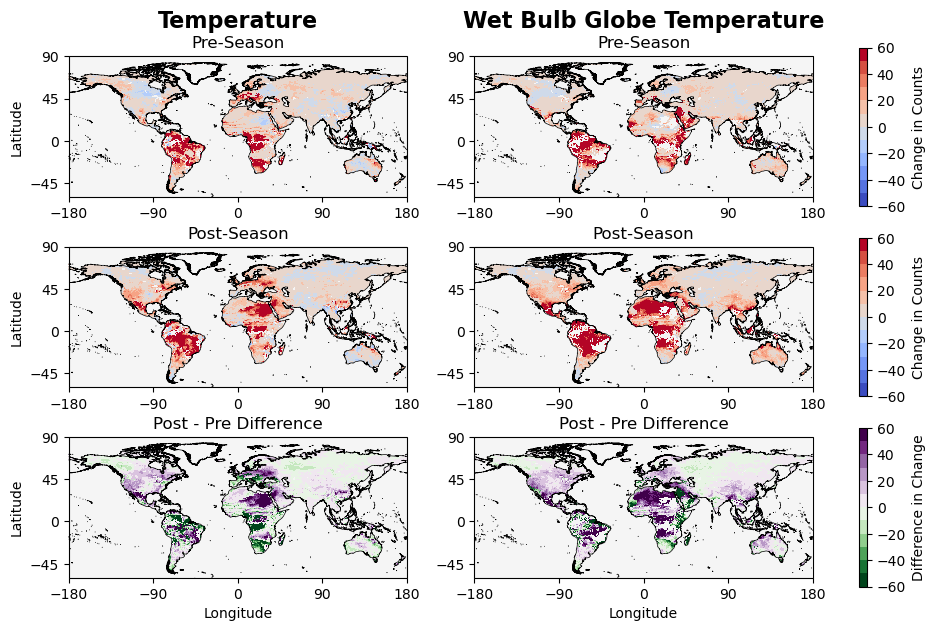

In [13]:
# Find difference between panel 2 and three in each figure
T_datasets = [before_extremes_T, after_extremes_T, after_extremes_T - before_extremes_T]
#T_datasets = [before_pad_T,after_pad_T, after_pad_T - before_pad_T]
WBGT_datasets = [before_extremes_WBGT,after_extremes_WBGT, after_extremes_WBGT - before_extremes_WBGT]
#WBGT_datasets = [before_pad_WBGT,after_pad_WBGT, after_pad_WBGT - before_pad_WBGT]

titles = ['Pre-Season','Post-Season', 'Post - Pre Difference']
#titles = ['Early Heat Season', 'Late Heat Season','Late - Early Difference']

cbar_labels = ['Change in Counts','Change in Counts','Difference in Change']
column_names = ['Temperature','Wet Bulb Globe Temperature']

datasets = [T_datasets,WBGT_datasets]

test_lon = -116.57
test_lat = 38.7

rows = 3
columns = 2

fig, axs = plt.subplots(rows,columns, figsize = (12,7), facecolor = 'w', edgecolor = 'k', subplot_kw = {'projection': ccrs.PlateCarree()})

for j, dataset in enumerate(datasets):
    
    for i, event_data in enumerate(dataset):
    
        plot_data_masked = event_data*mask_array
    
        plot_data_ds = xr.DataArray(plot_data_masked, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])
        if i == 2:
            cmap = matplotlib.cm.PRGn_r
        else:
            cmap = matplotlib.cm.coolwarm
    
        bounds = np.arange(-60, 60 + 10, 10) # if c
        ticks = np.arange(-60,60 + 20, 20)
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('whitesmoke',1.)
    
        mesh = axs[i,j].pcolormesh(plot_data_ds.lon, plot_data_ds.lat, plot_data_ds, norm = norm, cmap = cmap)
    
        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[i,j].plot(x,y, color = 'k', linewidth = 0.5)
    
        axs[i,j].set_title(titles[i])
        axs[i,j].set_xlim([-180,180])
        axs[i,j].set_ylim([-60,90])
        axs[i,j].set_xticks([-180,-90,0,90,180]);
        axs[i,j].set_yticks([-45,0,45,90]);
    
        if j == 0:
            axs[i,j].set_ylabel('Latitude')
        else:
            cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='vertical', ax = axs[i,:].ravel(),
                            label=cbar_labels[i])
            cbar.ax.set_yticks(ticks);
            cbar.ax.minorticks_off()
        if i == 2:
            axs[i,j].set_xlabel('Longitude')

        elif i == 0:
            axs[i,j].text(0.5, 1.25, column_names[j], transform=axs[i,j].transAxes, 
              fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')